# Model robustness: is the fossil phase-down finding model-specific?

**Question:** 1,599 scenarios come from 64 IAM model versions. If the PRIM/CART finding
(fossil primary energy < ~340 EJ/yr in 2050 is the key discriminator) is an artifact of
one model family's assumptions, it cannot be reported as a robust result.

**This notebook:**
1. Groups model versions into 9 IAM families
2. Plots desired_success rate by family
3. Checks whether CART feature importances agree across families
4. Shows what fraction of each family falls inside the PRIM-like fossil threshold

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)

data = pd.read_csv('../antoine_folder/data_for_scenariodiscovery_full.csv')
data['desired_success'] = data['desired_success'].astype(bool)
print(f'Loaded {data.shape[0]} scenarios, {data["desired_success"].sum()} desired_success ({data["desired_success"].mean():.1%})')

Loaded 1599 scenarios, 372 desired_success (23.3%)


In [2]:
# Group 64 model versions into 9 readable IAM families
def model_family(m):
    m = str(m).upper()
    if 'MESSAGEIX' in m or 'MESSAGE-GLOBI' in m or 'MESSAGEIX' in m: return 'MESSAGEix-GLOBIOM'
    if 'MESSAGE' in m: return 'MESSAGE-GLOBIOM'
    if 'REMIND' in m: return 'REMIND / REMIND-MAgPIE'
    if 'IMAGE' in m: return 'IMAGE'
    if 'WITCH' in m: return 'WITCH'
    if 'GCAM' in m: return 'GCAM'
    if 'AIM' in m: return 'AIM/CGE'
    if 'POLES' in m: return 'POLES'
    if 'GEM-E3' in m: return 'GEM-E3'
    if 'COFFEE' in m: return 'COFFEE'
    if 'IMACLIM' in m: return 'IMACLIM'
    if 'TIAM' in m: return 'TIAM-ECN'
    return 'Other'

data['family'] = data['Model'].apply(model_family)
print(data.groupby('family')[['desired_success']].agg(['count','sum','mean']).round(3))

                       desired_success            
                                 count  sum   mean
family                                            
AIM/CGE                             82   17  0.207
COFFEE                             100   19  0.190
GCAM                                77    9  0.117
GEM-E3                              58   22  0.379
IMACLIM                             22    4  0.182
IMAGE                              186   25  0.134
MESSAGEix-GLOBIOM                  334   87  0.260
Other                               40    0  0.000
POLES                              123   23  0.187
REMIND / REMIND-MAgPIE             362  129  0.356
TIAM-ECN                            47    9  0.191
WITCH                              168   28  0.167


C:\Users\rb1624\AppData\Local\Temp\ipykernel_34168\2579360683.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['family'] = data['Model'].apply(model_family)


## 1. Desired-success rate by model family

C:\Users\rb1624\AppData\Local\Temp\ipykernel_34168\112514940.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rb1624\AppData\Local\Temp\ipykernel_34168\112514940.py:29: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('model_robustness_rates.png', dpi=150, bbox_inches='tight')


C:\Users\rb1624\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


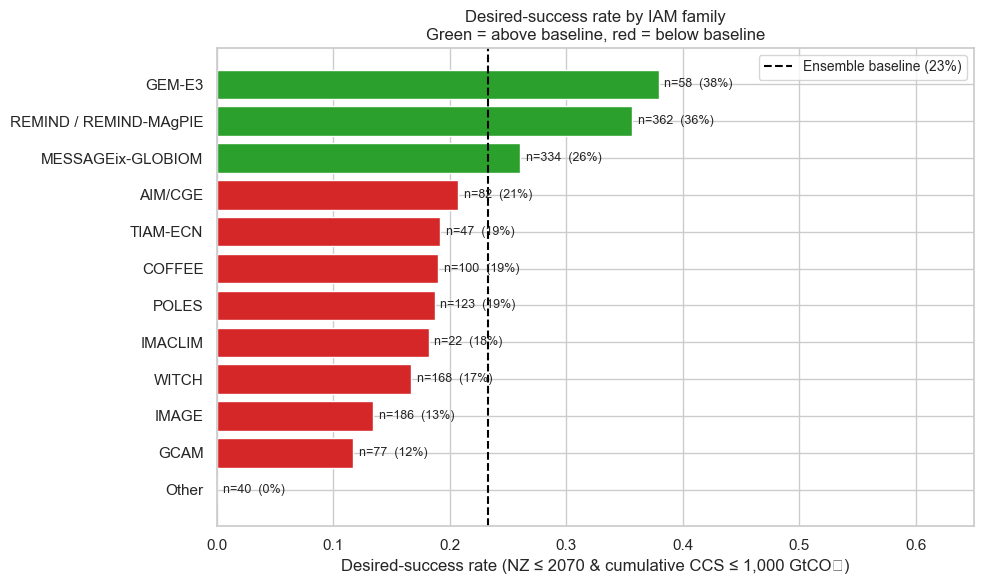

In [3]:
family_stats = (
    data.groupby('family')
    .agg(n=('desired_success','count'),
         n_desired=('desired_success','sum'))
    .assign(rate=lambda d: d['n_desired'] / d['n'])
    .sort_values('rate', ascending=True)
)
family_stats = family_stats[family_stats['n'] >= 5]  # drop families with <5 scenarios

baseline = data['desired_success'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ca02c' if r >= baseline else '#d62728' for r in family_stats['rate']]
bars = ax.barh(family_stats.index, family_stats['rate'], color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, family_stats.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n'])}  ({row['rate']:.0%})",
            va='center', fontsize=9)

ax.axvline(baseline, color='black', linewidth=1.5, linestyle='--',
           label=f'Ensemble baseline ({baseline:.0%})')
ax.set_xlabel('Desired-success rate (NZ ≤ 2070 & cumulative CCS ≤ 1,000 GtCO₂)')
ax.set_title('Desired-success rate by IAM family\n'
             'Green = above baseline, red = below baseline', fontsize=12)
ax.set_xlim(0, 0.65)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_robustness_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. CART feature importances by model family

Does every family agree that fossil phase-down is the key discriminator?

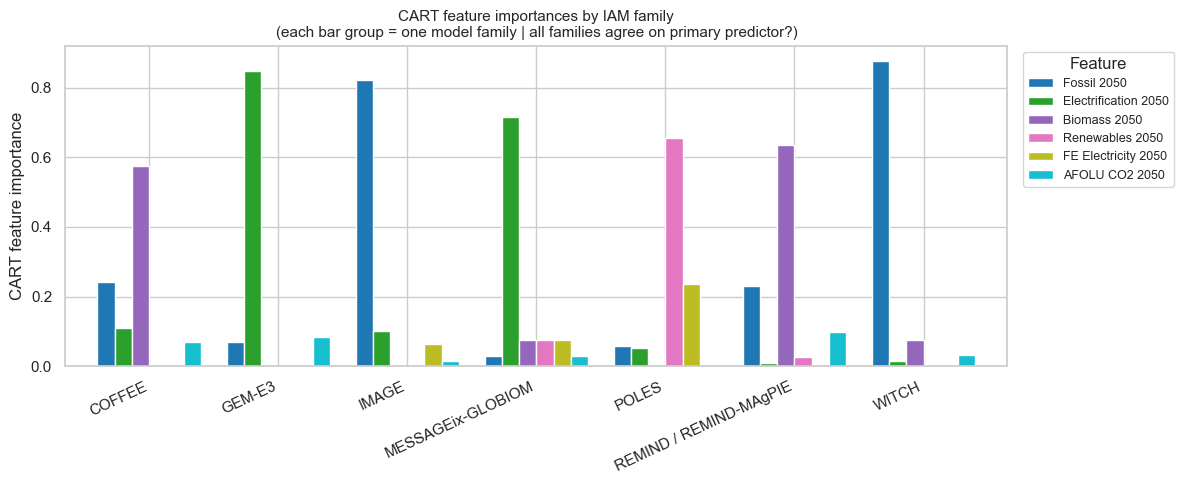

In [4]:
FACTORS = [
    'Primary Energy|Fossil|2050',
    'Primary Energy|Non-Biomass Renewables|2050',
    'Primary Energy|Biomass|2050',
    'Final Energy|Electricity|2050',
    'Electrification|2050',
    'Emissions|CO2|AFOLU|2050',
]
SHORT = {
    'Primary Energy|Fossil|2050':                  'Fossil 2050',
    'Primary Energy|Non-Biomass Renewables|2050':  'Renewables 2050',
    'Primary Energy|Biomass|2050':                 'Biomass 2050',
    'Final Energy|Electricity|2050':               'FE Electricity 2050',
    'Electrification|2050':                        'Electrification 2050',
    'Emissions|CO2|AFOLU|2050':                    'AFOLU CO2 2050',
}

records = []
BIG_FAMILIES = family_stats[family_stats['n'] >= 30].index.tolist()

for fam in BIG_FAMILIES:
    sub = data[data['family'] == fam][FACTORS + ['desired_success']].dropna()
    if sub['desired_success'].sum() < 10 or (~sub['desired_success']).sum() < 10:
        continue
    X, y = sub[FACTORS].values, sub['desired_success'].astype(int).values
    clf = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
    clf.fit(X, y)
    for feat, imp in zip(FACTORS, clf.feature_importances_):
        records.append({'family': fam, 'feature': SHORT[feat], 'importance': imp})

imp_df = pd.DataFrame(records)

pivot = imp_df.pivot(index='feature', columns='family', values='importance').fillna(0)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 5))
pivot.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.8)
ax.set_ylabel('CART feature importance')
ax.set_xlabel('')
ax.set_title('CART feature importances by IAM family\n'
             '(each bar group = one model family | all families agree on primary predictor?)',
             fontsize=11)
ax.legend(title='Feature', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('model_robustness_cart.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Fossil threshold capture rate by model family

The global CART root split is at ~340 EJ/yr fossil PE in 2050. For each model family:
how many scenarios fall below this threshold, and what fraction of those are desired-success?

Fossil threshold capture by model family:
                        n_total  n_below_thr  pct_below  desired_in_box  desired_rate
family                                                                               
GEM-E3                     58.0         42.0      0.724           0.524         0.379
REMIND / REMIND-MAgPIE    362.0        228.0      0.630           0.553         0.356
MESSAGEix-GLOBIOM         328.0        163.0      0.497           0.521         0.265
AIM/CGE                    81.0         21.0      0.259           0.619         0.210
TIAM-ECN                   47.0          1.0      0.021           1.000         0.191
COFFEE                    100.0         32.0      0.320           0.156         0.190
POLES                     123.0         68.0      0.553           0.338         0.187
WITCH                     168.0         83.0      0.494           0.337         0.167
IMAGE                     184.0         84.0      0.457           0.298         0.136
GCAM        

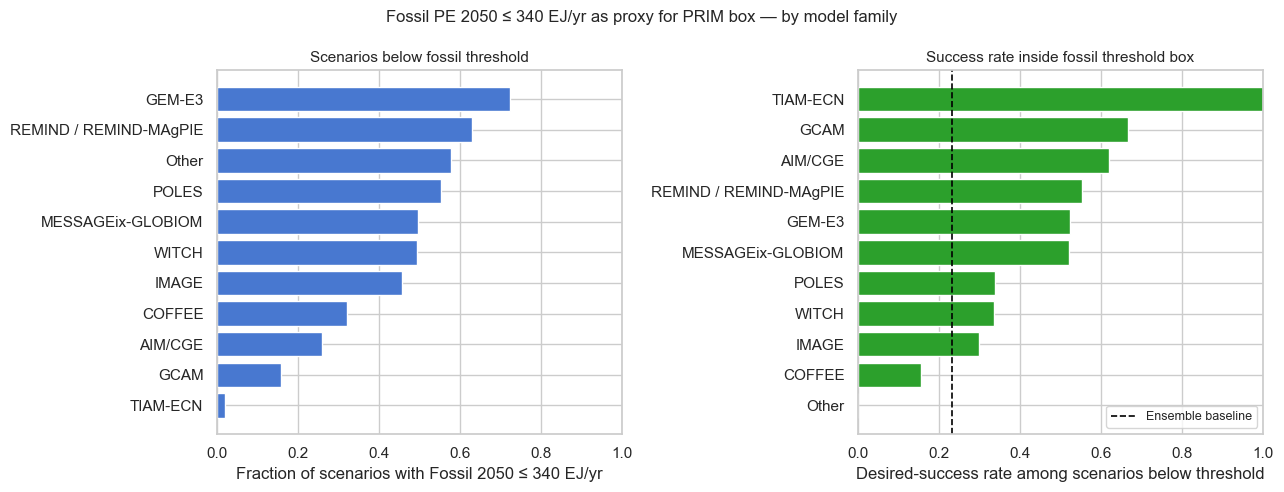

In [5]:
FOSSIL_COL = 'Primary Energy|Fossil|2050'
FOSSIL_THRESHOLD = 340  # EJ/yr — approximate CART root split

sub = data[data['family'].isin(BIG_FAMILIES)].dropna(subset=[FOSSIL_COL])

in_box = sub[FOSSIL_COL] <= FOSSIL_THRESHOLD
table = (
    sub.groupby('family')
    .apply(lambda g: pd.Series({
        'n_total':       len(g),
        'n_below_thr':   (g[FOSSIL_COL] <= FOSSIL_THRESHOLD).sum(),
        'pct_below':     (g[FOSSIL_COL] <= FOSSIL_THRESHOLD).mean(),
        'desired_in_box': (g.loc[g[FOSSIL_COL] <= FOSSIL_THRESHOLD, 'desired_success']).mean(),
        'desired_rate':  g['desired_success'].mean(),
    }), include_groups=False)
    .sort_values('desired_rate', ascending=False)
    .round(3)
)
print('Fossil threshold capture by model family:')
print(table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

table_sorted = table.sort_values('pct_below', ascending=True)
axes[0].barh(table_sorted.index, table_sorted['pct_below'],
             color='#4878d0', edgecolor='white')
axes[0].set_xlabel('Fraction of scenarios with Fossil 2050 ≤ 340 EJ/yr')
axes[0].set_title('Scenarios below fossil threshold', fontsize=11)
axes[0].set_xlim(0, 1)

table_sorted2 = table.sort_values('desired_in_box', ascending=True)
axes[1].barh(table_sorted2.index, table_sorted2['desired_in_box'],
             color='#2ca02c', edgecolor='white')
axes[1].axvline(data['desired_success'].mean(), color='black',
                linestyle='--', linewidth=1.2, label='Ensemble baseline')
axes[1].set_xlabel('Desired-success rate among scenarios below threshold')
axes[1].set_title('Success rate inside fossil threshold box', fontsize=11)
axes[1].set_xlim(0, 1)
axes[1].legend(fontsize=9)

fig.suptitle(f'Fossil PE 2050 ≤ {FOSSIL_THRESHOLD} EJ/yr as proxy for PRIM box — by model family',
             fontsize=12)
plt.tight_layout()
plt.savefig('model_robustness_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print('=== Model robustness summary ===')
print(f'Baseline desired_success rate (full ensemble): {data["desired_success"].mean():.1%}')
print()

top_feat_per_family = (
    imp_df.loc[imp_df.groupby('family')['importance'].idxmax()]
    .set_index('family')['feature']
)
fossil_top = (top_feat_per_family == 'Fossil 2050').sum()
print(f'Families where Fossil 2050 is top CART feature: {fossil_top}/{len(top_feat_per_family)}')
print(top_feat_per_family.to_string())
print()
if fossil_top == len(top_feat_per_family):
    print('→ Finding is ROBUST: fossil phase-down is the #1 predictor in every major model family.')
else:
    print('→ Partial robustness: some families diverge — see plot for details.')

=== Model robustness summary ===
Baseline desired_success rate (full ensemble): 23.3%

Families where Fossil 2050 is top CART feature: 2/7
family
COFFEE                            Biomass 2050
GEM-E3                    Electrification 2050
IMAGE                              Fossil 2050
MESSAGEix-GLOBIOM         Electrification 2050
POLES                          Renewables 2050
REMIND / REMIND-MAgPIE            Biomass 2050
WITCH                              Fossil 2050

→ Partial robustness: some families diverge — see plot for details.
